In [89]:
# Matrix Libraries
import pandas as pd
import numpy as np
import itertools

# Machine Learning Libraries
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder, OrdinalEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_validate, learning_curve
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay, precision_recall_curve, PrecisionRecallDisplay, average_precision_score, roc_curve, auc
from sklearn.linear_model import Perceptron, LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE, RandomOverSampler

from mlxtend.feature_selection import SequentialFeatureSelector as SFS

from xgboost import XGBClassifier

from scipy.stats import loguniform 

# Data Preprocessing Libraries
import missingno as msno

# Data Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

import sys
import warnings

warnings.filterwarnings("ignore")

In [2]:
# Load the data
Td = pd.read_csv('TelecomCustomerChurn.csv')

# **Telecom Customer Churn Prediction**

## Introduction

In this project, we aim to predict customer churn for a telecom company. Customer churn refers to the phenomenon where customers stop using a company's services. Predicting churn is crucial for businesses as it helps them take proactive measures to retain customers and improve their services.

## Dataset

The dataset used in this project is the "Telecom Customer Churn" dataset. It contains information about 7043 customers, including their demographics, account information, and services they have subscribed to. The dataset has 21 columns, each representing a different feature of the customer.

### Features

- `customerID`: Unique identifier for each customer.
- `Gender`: Gender of the customer (Male/Female).
- `SeniorCitizen`: Indicates if the customer is a senior citizen (1) or not (0).
- `Partner`: Indicates if the customer has a partner (Yes/No).
- `Dependents`: Indicates if the customer has dependents (Yes/No).
- `Tenure`: Number of months the customer has stayed with the company.
- `PhoneService`: Indicates if the customer has phone service (Yes/No).
- `MultipleLines`: Indicates if the customer has multiple lines (Yes/No).
- `InternetService`: Type of internet service the customer has (DSL/Fiber optic/No).
- `OnlineSecurity`: Indicates if the customer has online security service (Yes/No).
- `OnlineBackup`: Indicates if the customer has online backup service (Yes/No).
- `DeviceProtection`: Indicates if the customer has device protection service (Yes/No).
- `TechSupport`: Indicates if the customer has tech support service (Yes/No).
- `StreamingTV`: Indicates if the customer has streaming TV service (Yes/No).
- `StreamingMovies`: Indicates if the customer has streaming movies service (Yes/No).
- `Contract`: Type of contract the customer has (Month-to-month/One year/Two year).
- `PaperlessBilling`: Indicates if the customer has paperless billing (Yes/No).
- `PaymentMethod`: Payment method used by the customer (Electronic check/Mailed check/Bank transfer/Credit card).
- `MonthlyCharges`: The amount charged to the customer monthly.
- `TotalCharges`: The total amount charged to the customer.
- `Churn`: Indicates if the customer has churned (Yes/No).

The target variable in this dataset is `Churn`, which we aim to predict using the other features.

## Objective

The objective of this project is to build a machine learning model that can accurately predict whether a customer will churn or not based on their features. This will help the telecom company identify at-risk customers and take necessary actions to retain them.

---

# Data Visualization

In [3]:
Td

,customerID,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No,DSL,No,...,No,No,No,No,Monthly,Yes,Manual,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Manual,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Monthly,Yes,Manual,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Monthly,Yes,Manual,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Manual,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No,DSL,Yes,...,No,No,No,No,Monthly,Yes,Manual,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Monthly,Yes,Manual,74.40,306.6,Yes


In [4]:
Td.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   Gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   Tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


First thing to do is to modify the target column **Churn** with a <code>LableEncoder</code> so that we have numerical values as targets.

In [5]:
le = LabelEncoder()
Td['Churn'] = le.fit_transform(Td['Churn'])

There appear to be no missing values in the dataset based on the `info()` output. However, there's need to investigate further as there might be features with 'NaN' values represented as strings. Additionally, we need to convert the `TotalCharges` column to the `float64` data type for accurate analysis.

In [6]:
for col in Td.columns:
    print(col+':', Td[col].unique())
    print('-'*50)

customerID: ['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']
--------------------------------------------------
Gender: ['Female' 'Male']
--------------------------------------------------
SeniorCitizen: [0 1]
--------------------------------------------------
Partner: ['Yes' 'No']
--------------------------------------------------
Dependents: ['No' 'Yes']
--------------------------------------------------
Tenure: [ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26  0
 39]
--------------------------------------------------
PhoneService: ['No' 'Yes']
--------------------------------------------------
MultipleLines: ['No' 'Yes']
--------------------------------------------------
InternetService: ['DSL' 'Fiber optic' 'No']
--------------------------------------------------
OnlineSecurity: ['N

In [7]:
Td = Td.drop(columns=['customerID'])
# We will drop the customerID column as it is not useful for our analysis

Last remaing thing to do is convert the <code>TotalCharges</code> column into <code>float64</code>.

In [8]:
# Convert missing values coded as ' ' to '0.0' and convert the column to float
Td['TotalCharges'] = Td['TotalCharges'].replace(' ', '0.0')
Td['TotalCharges'] = Td['TotalCharges'].astype(float)

In [9]:
# Check for missing values coded as ' '
Td[Td ==' '].count()

Gender              0
SeniorCitizen       0
Partner             0
Dependents          0
Tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Now it's sure that there are no missing values in our dataset.

### Noise Adding

To better simulate real world experience I will use functions published by the professor to add noise to the dataset.

In [10]:
def add_missing(col, amount):
    X = col.copy()
    size = amount if amount >= 1 else int(len(X) * amount)
    indexes = np.random.choice(len(X), size, replace = False )
    X[indexes] = np.nan
    return X


In [11]:
# Add missing values to some columns
noise_col = ['Gender', 'Partner', 'Tenure', 'MultipleLines', 'InternetService', 'OnlineBackup', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']

for col in noise_col:
    if col == 'Gender':
        Td[col] = add_missing(Td[col], 0.5)
    Td[col] = add_missing(Td[col], 0.1)


In [12]:
Td.isnull().sum(axis=0)/Td.shape[0]

Gender              0.544086
SeniorCitizen       0.000000
Partner             0.099957
Dependents          0.000000
Tenure              0.099957
PhoneService        0.000000
MultipleLines       0.099957
InternetService     0.099957
OnlineSecurity      0.000000
OnlineBackup        0.099957
DeviceProtection    0.000000
TechSupport         0.000000
StreamingTV         0.000000
StreamingMovies     0.000000
Contract            0.000000
PaperlessBilling    0.099957
PaymentMethod       0.099957
MonthlyCharges      0.099957
TotalCharges        0.099957
Churn               0.000000
dtype: float64

Another way of visualizing missing data is through the <code>missingno</code> library.

<Axes: >

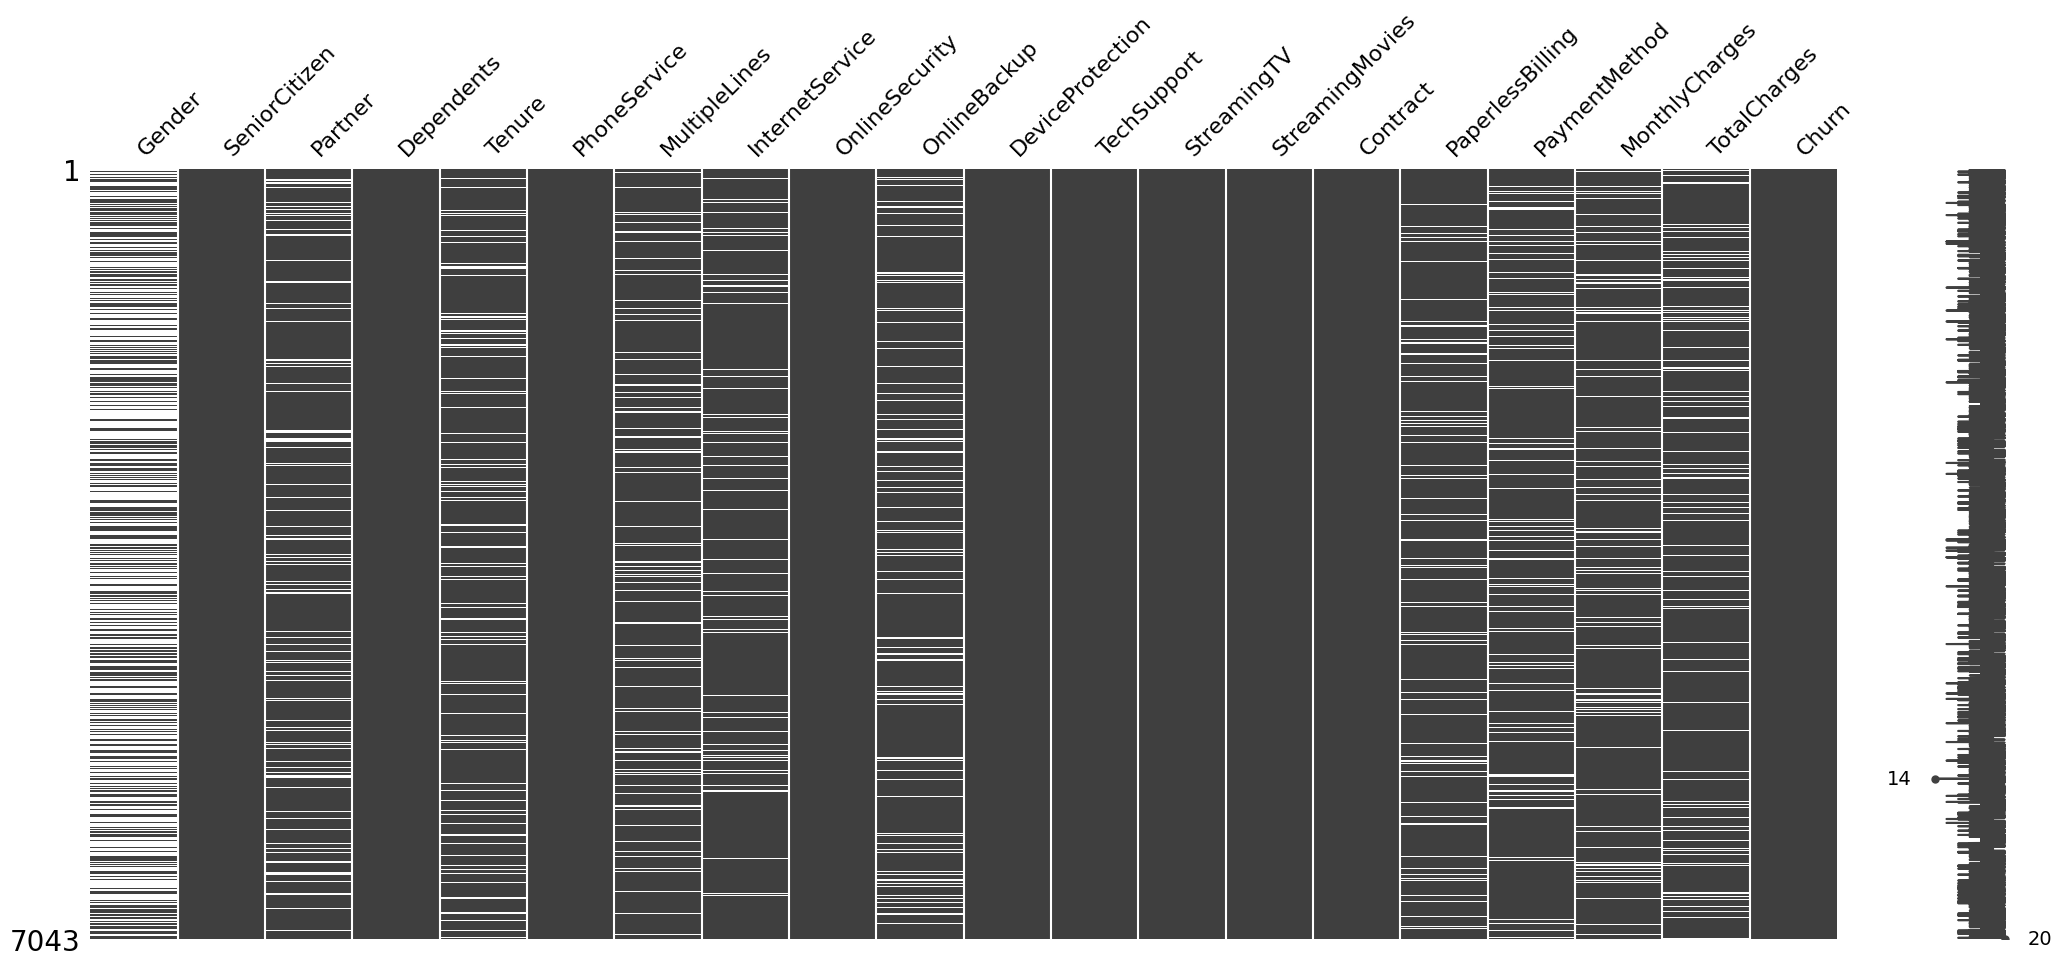

In [13]:
msno.matrix(Td)

# Data Transformation Pipeline

Now that a clear visualization of the dataset in its entirety is found, it's time to define the different pipelines of work that I will apply after the splitting.

### Pipeline1

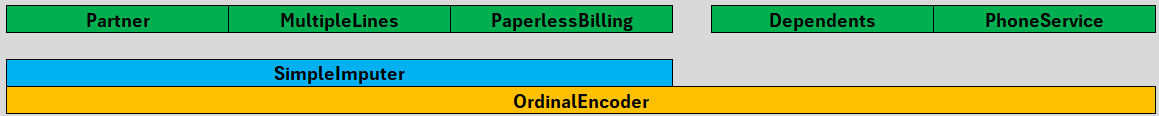

I will address the missing values in the columns: **Partner**, **MultipleLines**, and **PaperlessBilling** using the <code>SimpleImputer</code> from the *Sklearn* library. After imputing the missing values, I will encode the categorical values in these columns with the <code>OrdinalEncoder</code> from the *Sklearn* library.

### Pipeline2

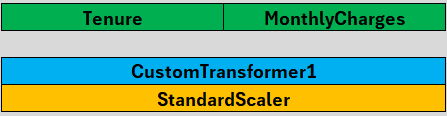

I will address the missing values in the columns **Tenure** and **MonthlyCharges** with a custom transformer and then scale the resulting values with the <code>StandardScaler</code> from the Sklearn library.

### Pipeline3

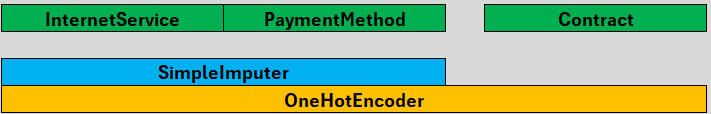

I will address the missing values in the column **InternetService** and **PaymentMethod** with the <code>SimpleImputer</code> from the Sklearn library. Then for all the columns showed I will use the **OneHotEncoder** to map each categorical feature of the column.

### Pipeline4

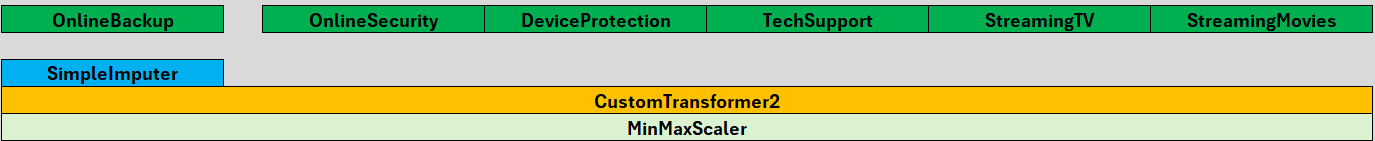

For the last pipeline, I will handle missing values in the **OnlineBackup** column using a <code>SimpleImputer</code>. To reduce complexity and create a more readable dataset, I will combine six columns into one that represents the number of extraservices of the customer. Then with the <code>MinMaxScaler</code> I will normalize the data.

___

The **Gender** column will be dropped due to high percentage of missing values.  
The **TotalCharges** column will be dropped since it's a linear combination of two other columns.  
The **SeniorCitizen** column is not present in any pipeline cause it was already in a good format.  

In [14]:
Td.drop(columns=['Gender'], inplace=True)

### Custom Transformers

The first custom transformer will deal with missing values in the **Tenure** and **MonthlyCharges** columns using the linear relationship that can be found between **Tenure**,**MonthlyCharges** and **TotalCharges**. $$\text{Tenure} = {\text{TotalCharges}\over\text{MonthlyCharges}}$$ After it will drop the **TotalCharges** column to avoid multicollinaerity.

In [15]:
class CustomTransformer1(BaseEstimator, TransformerMixin):
    def __init__(self, tenure_col="Tenure", monthly_col="MonthlyCharges", total_col="TotalCharges"):
        self.tenure_col = tenure_col
        self.monthly_col = monthly_col
        self.total_col = total_col

    def fit(self, X, y=None):
        return self
    
    def transform(self, X):

        ## Fill missing values in the tenure column
        mask = X[self.tenure_col].isna()
        X.loc[mask, self.tenure_col] = (X[self.total_col] / X[self.monthly_col])

        ## Fill missing values in the monthly charges column
        mask = X[self.monthly_col].isna()
        X.loc[mask, self.monthly_col] = (X[self.total_col] / X[self.tenure_col])

        ## Convert Tenure to integer for easier manipulation
        X[self.tenure_col] = X[self.tenure_col].astype(int)

        ## Convert MonthlyCharges to two point decimal
        X[self.monthly_col] = X[self.monthly_col].round(2)

        ## Drop the TotalCharges column since it's a linear combination of Tenure and MonthlyCharges
        X = X.drop(columns=[self.total_col])

        return X



The second custom transformer will combine togheter the: **OnlineSecurity**, **OnlineBackup**, **DeviceProtection**, **TechSupport**, **StreamingTV**, **StreamingMovies** columns, in a single one, that will represent the number of services each customer has.

In [16]:
class CustomTransformer2(BaseEstimator, TransformerMixin):
    def __init__(self, online_security='OnlineSecurity', online_backup='OnlineBackup', device_protection='DeviceProtection', tech_support='TechSupport', steaming_tv='StreamingTV', streaming_movies='StreamingMovies'):
        self.online_security = online_security
        self.online_backup = online_backup
        self.device_protection = device_protection
        self.tech_support = tech_support
        self.steaming_tv = steaming_tv
        self.streaming_movies = streaming_movies

    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        
        ## Create a list of the extra service columns
        extraservices = [self.online_security, self.online_backup, self.device_protection, self.tech_support, self.steaming_tv, self.streaming_movies]
        
        ## Create the ExtraServices column and assign the values of the sum of the other columns
        Y = (X == 'Yes').sum(axis=1)
                
        return Y.reshape(-1, 1)




___

The last thing we have to do before creating the pipelines and the **ColumnTransformer** is to drop some problematic rows that could mess with the custom transformers:
- Drop rows where more than 1 value between **Tenure**, **MonthlyCharges**, **TotalCharges** are <code>NaN</code>
- Drop rows where **MonthlyCharges** has value *zero*
- Drop rows where **MonthlyCharges** value is missing and **Tenure** has value zero

In [17]:
## Create the first mask to detect rows where at least 2 of the values of columns Tenure, MonthlyCharges and TotalCharges are missing
mask_1 = (Td[['Tenure', 'MonthlyCharges', 'TotalCharges']].isna().sum(axis=1) >= 2)
Td.drop(index=Td[mask_1].index, inplace=True)

## Create the second mask to detect rows where MonthlyCharges or Tenure have value zero
mask_2 = Td['MonthlyCharges'] == 0
Td.drop(index=Td[mask_2].index, inplace=True)

## Create the third mask to detect rows where MonthlyCharges is NaN and Tenure is zero
mask_3 = Td['MonthlyCharges'].isna() & (Td['Tenure'] == 0)
Td.drop(index=Td[mask_3].index, inplace=True)

In [18]:
pipeline1 = Pipeline([
    ('imp', SimpleImputer(strategy='most_frequent')),
    ('lable', OrdinalEncoder())
])

pipeline2 = Pipeline([
    ('custom1', CustomTransformer1()),
    ('scaler', StandardScaler())
])

pipeline3 = Pipeline([
    ('imp', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first'))
])

pipeline4 = Pipeline([
    ('imp', SimpleImputer(strategy='most_frequent')),
    ('custom2', CustomTransformer2()),
    ('scaler', MinMaxScaler())
    
])

final_transformer = ColumnTransformer(transformers=[
    ('pipeline1', pipeline1, ['Partner', 'MultipleLines', 'PaperlessBilling', 'Dependents', 'PhoneService']),
    ('pipeline2', pipeline2, ['Tenure', 'MonthlyCharges', 'TotalCharges']),
    ('pipeline3', pipeline3, ['InternetService', 'PaymentMethod', 'Contract']),
    ('pipeline4', pipeline4, ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies'])
],
remainder = 'passthrough',
verbose_feature_names_out = False,
sparse_threshold = 0
)

# Train & Test split

Now that the <code>final_transformer</code> has been defined I Have to split the dataset into **Train** and **Test**.

In [19]:
## Define the target variable
y = Td['Churn']

## Define the features
X = Td.drop(columns=['Churn'])

## Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

We now define the starting pipeline

In [20]:
pip = ImbPipeline([
    ('transformer', final_transformer),
    ('sampler', SMOTE()),
    ('dim_reduction', PCA()),
    ('classifier', Perceptron())
])

In [21]:
pip.fit(X_train, y_train)

Pipeline(steps=[('transformer',
                 ColumnTransformer(remainder='passthrough', sparse_threshold=0,
                                   transformers=[('pipeline1',
                                                  Pipeline(steps=[('imp',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('lable',
                                                                   OrdinalEncoder())]),
                                                  ['Partner', 'MultipleLines',
                                                   'PaperlessBilling',
                                                   'Dependents',
                                                   'PhoneService']),
                                                 ('pipeline2',
                                                  Pipeline(steps=[('custom1',
                                                                   CustomTransformer1()),...
                                                   'Contract']),
                                                 ('pipeline4',
                                                  Pipeline(steps=[('imp',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('custom2',
                                                                   CustomTransformer2()),
                                                                  ('scaler',
                                                                   MinMaxScaler())]),
                                                  ['OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies'])],
                                   verbose_feature_names_out=False)),
                ('sampler', SMOTE()), ('dim_reduction', PCA()),
                ('classifier', Perceptron())])

# Model Selection

We define all the elements needed for the search of the best possible model. The final output will be a list of 5 piplines consisting of:
- **final_transformer**
- **dimensionality reduction**
- handling of **imbalanced classes**
- **classification**

The following are the models and configurations we will use:
- For Sampling, we'll try to use SMOTE (Synthetic Minority Over-sampling Technique) and a RandomOverSampler.
- For Dimensionality Reduction we will try to use PCA, LDA and SequentialFeatureSelector that uses Perceptron or LogisticRegression as estimators.
- For classifiers, we'll try different configurations of Perceptron, LogisticRegression, KNeighbors, RandomForest, SVC, XGBoost and GradientBoostingClassifier.

In [22]:
sampler_configs = [
    {
        'sampler':[None] # The element is bypassed
    },
    {
        'sampler':[SMOTE()],
        'sampler__sampling_strategy':['minority', 1.2, 0.9, 0.7]
    },
    {
        'sampler':[RandomOverSampler()],
        'sampler__sampling_strategy':['minority', 1.2, 0.9, 0.7]
    }
]

dim_reduction_configs = [
    {
        'dim_reduction': [None] # The element is bypassed
    },
    {
        'dim_reduction': [PCA()],
        'dim_reduction__n_components': [0.5, 0.7, 0.9]
    },
    {
        'dim_reduction': [LDA()]
    },
    {
        'dim_reduction': [SFS(estimator=Perceptron(), cv = None, scoring = 'f1')],
        'dim_reduction__estimator': [Perceptron(), LogisticRegression()],
        'dim_reduction__k_features' : [5,7,10]
    }
]

classifier_configs = [
    {
        'classifier__eta0' : loguniform(0.001,100),
        'classifier': [Perceptron()] ,
        'classifier__max_iter': [1,5,10,15,50,100] ,
        'classifier__class_weight' : [None, 'balanced']

    },
    {
        'classifier': [LogisticRegression(solver='saga')],
        'classifier__C' : loguniform(1e-2, 1e1),
        'classifier__penalty': ['l1','l2'],
        'classifier__class_weight' : [None, 'balanced']

    },
    {
        'classifier': [KNeighborsClassifier()],
        'classifier__n_neighbors': [1,3,5,7,9]
    },
    {
        'classifier' : [RandomForestClassifier()],
        'classifier__n_estimators' : [10, 25, 50, 100, 125]
    },
    {
        'classifier': [SVC()],
        'classifier__C': loguniform(1e-2, 1e1),
        'classifier__kernel': ['linear', 'poly', 'rbf', 'sigmoid'],
        'classifier__gamma': loguniform(1e-4, 1),
        'classifier__class_weight': [None, 'balanced'],
    },
    {
        'classifier': [XGBClassifier(use_label_encoder=False, eval_metric='logloss')],
        'classifier__n_estimators': [100, 150, 200, 250, 300],
        'classifier__learning_rate': loguniform(0.01, 0.03),
        'classifier__max_depth': [3, 6, 9],
        'classifier__subsample': [0.7, 0.8, 1.0]
    },
    {
        'classifier': [GradientBoostingClassifier()],
        'classifier__n_estimators': [100, 150, 200, 250, 300],
        'classifier__learning_rate': loguniform(0.01, 0.03),
        'classifier__max_depth': [3, 6, 9],
        'classifier__subsample': [0.7, 0.8, 1.0],
        'classifier__min_samples_split': [2, 5, 10],
        'classifier__min_samples_leaf': [1, 2, 4],
        'classifier__max_features': ['auto', 'sqrt', 'log2', None],
        'classifier__loss': ['deviance', 'exponential']
    }
]

Now using the **product** of the <code>itertools</code> module, we can enumerate all the possible configuration of this elements.

In [23]:
all_configs = [dict(itertools.chain(*(e.items() 
for e in configuration))) 
for configuration in 
itertools.product(sampler_configs,dim_reduction_configs,classifier_configs)]

In [24]:
print('Total number of configurations:', len(all_configs))

Total number of configurations: 84


We will now use **nested cross-validation** to find the best pipeline out of the 84 possible configuration we created using <code>itertools</code>. We do so with <code>RandomizedSearchCV</code> which implements the inner loop of **cross-validation**.

In [25]:
rs = RandomizedSearchCV(pip,
    param_distributions=all_configs,
    n_iter=len(all_configs) * 5,
    n_jobs=-1,
    cv = 2,
    scoring='f1'
)

We now use <code>cross_validate</code> to perform the outer loop of the **cross-validation** and find the best models according to the *f1* scoring sistem.

In [26]:
scores = cross_validate(rs, X_train, y_train, cv=5, scoring='f1', return_estimator=True, verbose=1)

Now with a for loop, we print the five best models.

In [27]:
for index, estimator in enumerate(scores['estimator']):
    print(estimator.best_estimator_.get_params()['sampler'])
    print(estimator.best_estimator_.get_params()['dim_reduction'])
    print(estimator.best_estimator_.get_params()['classifier'],estimator.best_estimator_.get_params()['classifier'].get_params())
    print(scores['test_score'][index])
    print('-'*10)

SMOTE(sampling_strategy=0.7)
LinearDiscriminantAnalysis()
SVC(C=np.float64(0.31182703898210473), gamma=np.float64(0.0005521851145561981),
    kernel='linear') {'C': np.float64(0.31182703898210473), 'break_ties': False, 'cache_size': 200, 'class_weight': None, 'coef0': 0.0, 'decision_function_shape': 'ovr', 'degree': 3, 'gamma': np.float64(0.0005521851145561981), 'kernel': 'linear', 'max_iter': -1, 'probability': False, 'random_state': None, 'shrinking': True, 'tol': 0.001, 'verbose': False}
0.6476462196861626
----------
SMOTE(sampling_strategy='minority')
None
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=np.float64(0

To get an even better understanding of the actual performance of the model we re-train the models on the *train-set* and then evaluate their performance on the *test-set*.

In [28]:
for estimator in scores['estimator']:
    pred_train = estimator.best_estimator_.fit(X_train, y_train)
    pred_train = estimator.best_estimator_.predict(X_train)
    pred_test = estimator.best_estimator_.predict(X_test)
    f1_train = f1_score(y_train, pred_train)
    f1_test = f1_score(y_test, pred_test)
    print(f'F1 on training set:{f1_train}, F1 on test set:{f1_test}')

F1 on training set:0.6267772511848341, F1 on test set:0.6286379511059371
F1 on training set:0.6437889960294951, F1 on test set:0.6300768386388584
F1 on training set:0.627569197040285, F1 on test set:0.6268980477223427
F1 on training set:0.6520432692307693, F1 on test set:0.6283704572098476
F1 on training set:0.6466706658668266, F1 on test set:0.6401869158878505


As we can see none of the five models has an *f1* score above 0.7 which is considered a good benchmark; altough the score on test and train stays the same for all models so we don't experience overfitting. In order to increase performance we can maybe increase the dimension of the dataset, by inverting the change implemented by the second custom transformer.

In [29]:
## MODIFY THE PIPELINE4, DELETING THE CUSTOMTERANSFORMER2 AND REPLACING IT WITH A SIMPLE ORDINAL ENCODER
pipeline4 = Pipeline([
    ('imp', SimpleImputer(strategy='most_frequent')),
    ('lable', OrdinalEncoder()) 
    
])

final_transformer = ColumnTransformer(transformers=[
    ('pipeline1', pipeline1, ['Partner', 'MultipleLines', 'PaperlessBilling', 'Dependents', 'PhoneService']),
    ('pipeline2', pipeline2, ['Tenure', 'MonthlyCharges', 'TotalCharges']),
    ('pipeline3', pipeline3, ['InternetService', 'PaymentMethod', 'Contract']),
    ('pipeline4', pipeline4, ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies'])
],
remainder = 'passthrough',
verbose_feature_names_out = False,
sparse_threshold = 0
)

We can no try and re-run the **nested cross-validation** using this *final_transformer*.

In [30]:
pip2 = ImbPipeline([
    ('transformer', final_transformer),
    ('sampler', SMOTE()),
    ('dim_reduction', PCA()),
    ('classifier', Perceptron())
])

pip2.fit(X_train, y_train)

  File "C:\Users\robyt\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.12_3.12.2544.0_x64__qbz5n2kfra8p0\Lib\subprocess.py", line 550, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.12_3.12.2544.0_x64__qbz5n2kfra8p0\Lib\subprocess.py", line 1028, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.12_3.12.2544.0_x64__qbz5n2kfra8p0\Lib\subprocess.py", line 1540, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

Pipeline(steps=[('transformer',
                 ColumnTransformer(remainder='passthrough', sparse_threshold=0,
                                   transformers=[('pipeline1',
                                                  Pipeline(steps=[('imp',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('lable',
                                                                   OrdinalEncoder())]),
                                                  ['Partner', 'MultipleLines',
                                                   'PaperlessBilling',
                                                   'Dependents',
                                                   'PhoneService']),
                                                 ('pipeline2',
                                                  Pipeline(steps=[('custom1',
                                                                   CustomTransformer1()),...
                                                  ['InternetService',
                                                   'PaymentMethod',
                                                   'Contract']),
                                                 ('pipeline4',
                                                  Pipeline(steps=[('imp',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('lable',
                                                                   OrdinalEncoder())]),
                                                  ['OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies'])],
                                   verbose_feature_names_out=False)),
                ('sampler', SMOTE()), ('dim_reduction', PCA()),
                ('classifier', Perceptron())])

In [31]:
rs2 = RandomizedSearchCV(pip2,
    param_distributions=all_configs,
    n_iter=len(all_configs) * 5,
    n_jobs=-1,
    cv = 2,
    scoring='f1'
)

In [32]:
scores2 = cross_validate(rs2, X_train, y_train, cv=5, scoring='f1', return_estimator=True, verbose=2)

[CV] END .................................................... total time=  50.7s
[CV] END .................................................... total time=  43.4s
[CV] END .................................................... total time=  49.8s
[CV] END .................................................... total time=  58.9s
[CV] END .................................................... total time=  46.6s


In [33]:
for index, estimator in enumerate(scores2['estimator']):
    print(estimator.best_estimator_.get_params()['sampler'])
    print(estimator.best_estimator_.get_params()['dim_reduction'])
    print(estimator.best_estimator_.get_params()['classifier'],estimator.best_estimator_.get_params()['classifier'].get_params())
    print(scores2['test_score'][index])
    print('-'*10)

RandomOverSampler(sampling_strategy=0.9)
LinearDiscriminantAnalysis()
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=np.float64(0.012181399046820503), max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=150, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...) {'objective': 'binary:logistic', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_by

In [34]:
for estimator in scores2['estimator']:
    pred_train = estimator.best_estimator_.fit(X_train, y_train)
    pred_train = estimator.best_estimator_.predict(X_train)
    pred_test = estimator.best_estimator_.predict(X_test)
    f1_train = f1_score(y_train, pred_train)
    f1_test = f1_score(y_test, pred_test)
    print(f'F1 on training set:{f1_train}, F1 on test set:{f1_test}')

F1 on training set:0.63316002310803, F1 on test set:0.632768361581921
F1 on training set:0.6331428571428571, F1 on test set:0.6274944567627494
F1 on training set:0.642369020501139, F1 on test set:0.6305309734513275
F1 on training set:0.6285559468978597, F1 on test set:0.6276595744680851
F1 on training set:0.6513843405775528, F1 on test set:0.6329113924050633


We can see a decent increse in score between the two different transformers, so we will keep as valid these last results.

We can select the best model based on this scoring, and since the best scoring model  utilize the <code>XGBClassifier</code>, we can safely assume that it is the best model for our dataset.

## HyperParameter Optimization

Since we have established which the best model is, we can run once again a **nested cross-validation** in order to have the best ranges og hyperparameters and the best combiantions of sampling and dimensionality reduction tools.

In [ ]:
best_pip = ImbPipeline([
    ('transformer', final_transformer),
    ('sampler', SMOTE()),
    ('dim_reduction', PCA(n_components=0.8)),
    ('classifier', XGBClassifier())
])

In [49]:
sampler_configs = [
    {
        'sampler':[None]
    },
    {
        'sampler':[SMOTE()],
        'sampler__sampling_strategy':['minority', 1.2, 0.9, 0.7]
    },
    {
        'sampler':[RandomOverSampler()],
        'sampler__sampling_strategy':['minority', 1.2, 0.9, 0.7]
    }
]

dim_reduction_configs = [
    {
        'dim_reduction': [None]
    },
    {
        'dim_reduction': [PCA()],
        'dim_reduction__n_components': [0.5, 0.7, 0.9]
    },
    {
        'dim_reduction': [LDA()]
    },
    {
        'dim_reduction': [SFS(estimator=Perceptron(), cv = None, scoring = 'f1')],
        'dim_reduction__estimator': [Perceptron(), LogisticRegression()],
        'dim_reduction__k_features' : [5,7,10]
    }
]

classifier_configs = [
    {
        'classifier': [XGBClassifier(use_label_encoder=False, eval_metric='logloss')],
        'classifier__n_estimators': [100, 150, 200, 250, 300],
        'classifier__learning_rate': loguniform(0.01, 0.03),
        'classifier__max_depth': [3, 6, 9],
        'classifier__subsample': [0.7, 0.8, 1.0]
    }
]

In [50]:
best_configs = [dict(itertools.chain(*(e.items() 
for e in configuration))) 
for configuration in 
itertools.product(sampler_configs,dim_reduction_configs,classifier_configs)]

print('Total number of configurations:', len(best_configs))

Total number of configurations: 12


We now run **nested cross-validation** on this set of possible configuration.

In [51]:
## INNER LOOP
best_rs = RandomizedSearchCV(best_pip,
    param_distributions=best_configs,
    n_iter=len(best_configs) * 10, ## Increase the number of iterations for optimization
    n_jobs=-1,
    cv = 2,
    scoring='f1'
)

## OUTER LOOP
best_scores = cross_validate(best_rs, X_train, y_train, cv=5, scoring='f1', return_estimator=True, verbose=2)

[CV] END .................................................... total time=  19.8s
[CV] END .................................................... total time=  13.4s
[CV] END .................................................... total time=  14.1s
[CV] END .................................................... total time=  13.7s
[CV] END .................................................... total time=  13.7s


And run again the procedure to get the 5 best models out.

In [52]:
for index, estimator in enumerate(best_scores['estimator']):
    print(estimator.best_estimator_.get_params()['sampler'])
    print(estimator.best_estimator_.get_params()['dim_reduction'])
    print(estimator.best_estimator_.get_params()['classifier'],estimator.best_estimator_.get_params()['classifier'].get_params())
    print(best_scores['test_score'][index])
    print('-'*10)

RandomOverSampler(sampling_strategy=0.9)
LinearDiscriminantAnalysis()
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=np.float64(0.016077906841471666), max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...) {'objective': 'binary:logistic', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_by

In [53]:
for estimator in best_scores['estimator']:
    pred_train = estimator.best_estimator_.fit(X_train, y_train)
    pred_train = estimator.best_estimator_.predict(X_train)
    pred_test = estimator.best_estimator_.predict(X_test)
    f1_train = f1_score(y_train, pred_train)
    f1_test = f1_score(y_test, pred_test)
    print(f'F1 on training set:{f1_train}, F1 on test set:{f1_test}')

F1 on training set:0.6343241727425687, F1 on test set:0.6296296296296297
F1 on training set:0.6332305968058279, F1 on test set:0.6247288503253796
F1 on training set:0.6364409181071125, F1 on test set:0.6341463414634146
F1 on training set:0.6454207920792079, F1 on test set:0.6351829988193625
F1 on training set:0.6334894613583139, F1 on test set:0.625


We can further select the best configuration:
- The best sampler is still unclear
- The best dimensionality reduction is either <code>LDA</code> or <code>None</code>  


As for the hyperparameters of <code>XGBClassifier</code> we will try all that appeared on the last search and also explore in more detail the ranges.

In [54]:
sampler_configs = [
    {
        'sampler':[None]
    },
    {
        'sampler':[SMOTE()],
        'sampler__sampling_strategy':['minority', 1.2, 0.9, 0.7]
    },
    {
        'sampler':[RandomOverSampler()],
        'sampler__sampling_strategy':['minority', 1.2, 0.9, 0.7]
    }
]

dim_reduction_configs = [
    {
        'dim_reduction': [None]
    },
    {
        'dim_reduction': [LDA()]
    }
]

classifier_configs = [
    {
        'classifier': [XGBClassifier(use_label_encoder=False, eval_metric='logloss')],
        'classifier__n_estimators': [50, 100, 150, 200, 250, 300, 350, 400], ## Increase the range of the number of estimators
        'classifier__learning_rate': loguniform(0.01, 0.04), ## Increase the range of the learning rate
        'classifier__max_depth': [3, 6, 9],
        'classifier__subsample': [0.5, 0.7, 0.8, 1.0, 1.2, 1.5] ## Increase the range of the subsample
    }
]

In [56]:
evenbetter_configs = [dict(itertools.chain(*(e.items() 
for e in configuration))) 
for configuration in 
itertools.product(sampler_configs,dim_reduction_configs,classifier_configs)]

print('Total number of configurations:', len(evenbetter_configs))

Total number of configurations: 6


In [57]:
## INNER LOOP
evenbetter_rs = RandomizedSearchCV(best_pip,
    param_distributions=evenbetter_configs,
    n_iter=len(evenbetter_configs) * 20, ## Increase the number of iterations for optimization
    n_jobs=-1,
    cv = 2,
    scoring='f1'
)

## OUTER LOOP
evenbetter_scores = cross_validate(evenbetter_rs, X_train, y_train, cv=5, scoring='f1', return_estimator=True, verbose=2)

[CV] END .................................................... total time=  11.1s
[CV] END .................................................... total time=   6.9s
[CV] END .................................................... total time=   7.1s
[CV] END .................................................... total time=   7.0s
[CV] END .................................................... total time=   6.1s


Further analyze this models to find the final and best one.

In [58]:
for index, estimator in enumerate(evenbetter_scores['estimator']):
    print(estimator.best_estimator_.get_params()['sampler'])
    print(estimator.best_estimator_.get_params()['dim_reduction'])
    print(estimator.best_estimator_.get_params()['classifier'],estimator.best_estimator_.get_params()['classifier'].get_params())
    print(evenbetter_scores['test_score'][index])
    print('-'*10)

RandomOverSampler(sampling_strategy='minority')
None
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=np.float64(0.011765655649728979), max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=350, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...) {'objective': 'binary:logistic', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'col

In [59]:
for estimator in evenbetter_scores['estimator']:
    pred_train = estimator.best_estimator_.fit(X_train, y_train)
    pred_train = estimator.best_estimator_.predict(X_train)
    pred_test = estimator.best_estimator_.predict(X_test)
    f1_train = f1_score(y_train, pred_train)
    f1_test = f1_score(y_test, pred_test)
    print(f'F1 on training set:{f1_train}, F1 on test set:{f1_test}')

F1 on training set:0.6339027595269382, F1 on test set:0.6243602865916069
F1 on training set:0.643284393692224, F1 on test set:0.6240837696335079
F1 on training set:0.6610416060517893, F1 on test set:0.6351351351351351
F1 on training set:0.6430732002419842, F1 on test set:0.6302325581395349
F1 on training set:0.6502433090024331, F1 on test set:0.6384976525821596


We can see that the best model is the third, and it uses:
- **Sampler** = <code>Smote</code> with sampling strategy *minority*
- **Dim_reduction** = <code>None</code>


Since it's not yet clear which model is best, we'll keep also the <code>RandomOverSampler</code> and further analyze the hyperparameters of the <code>XGBClassifier</code>.

In [66]:
sampler_configs = [
    {
        'sampler':[SMOTE()],
        'sampler__sampling_strategy':['minority', 0.7] ## Limit the sampling strategy to the one that performed best
    },
    {
        'sampler':[RandomOverSampler()],
        'sampler__sampling_strategy':['minority', 0.9, 0.7] ## Limit the sampling strategy to the one that performed best
    }
]

dim_reduction_configs = [
    {
        'dim_reduction': [None]
    }
]

classifier_configs = [
    {    
        'classifier': [XGBClassifier(use_label_encoder=False, eval_metric='logloss')],
        'classifier__n_estimators': [50, 100, 150, 200, 250, 300, 350, 400], ## Increase the range of the number of estimators
        'classifier__learning_rate': loguniform(0.01, 0.04), ## Increase the range of the learning rate
        'classifier__max_depth': [3, 6],
        'classifier__subsample': [0.5, 0.7, 0.8, 1.0, 1.2, 1.5] ## Increase the range of the subsample
    }   
]

In [67]:
final_configs = [dict(itertools.chain(*(e.items() 
for e in configuration))) 
for configuration in 
itertools.product(sampler_configs,dim_reduction_configs,classifier_configs)]

print('Total number of configurations:', len(final_configs))

Total number of configurations: 2


In [68]:
## INNER LOOP
final_rs = RandomizedSearchCV(best_pip,
    param_distributions=final_configs,
    n_iter=len(final_configs) * 50, ## Increase the number of iterations by a lot for the final optimization
    n_jobs=-1,
    cv = 2,
    scoring='f1'
)

## OUTER LOOP
final_scores = cross_validate(final_rs, X_train, y_train, cv=5, scoring='f1', return_estimator=True, verbose=2)

[CV] END .................................................... total time=   8.9s
[CV] END .................................................... total time=   5.7s
[CV] END .................................................... total time=   6.0s
[CV] END .................................................... total time=   6.8s
[CV] END .................................................... total time=   5.8s


Let's visualize these last results.

In [69]:
for index, estimator in enumerate(final_scores['estimator']):
    print(estimator.best_estimator_.get_params()['sampler'])
    print(estimator.best_estimator_.get_params()['dim_reduction'])
    print(estimator.best_estimator_.get_params()['classifier'],estimator.best_estimator_.get_params()['classifier'].get_params())
    print(final_scores['test_score'][index])
    print('-'*10)

RandomOverSampler(sampling_strategy='minority')
None
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=np.float64(0.014674471652044923), max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=250, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...) {'objective': 'binary:logistic', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'col

In [70]:
for estimator in final_scores['estimator']:
    pred_train = estimator.best_estimator_.fit(X_train, y_train)
    pred_train = estimator.best_estimator_.predict(X_train)
    pred_test = estimator.best_estimator_.predict(X_test)
    f1_train = f1_score(y_train, pred_train)
    f1_test = f1_score(y_test, pred_test)
    print(f'F1 on training set:{f1_train}, F1 on test set:{f1_test}')

F1 on training set:0.6308654848800834, F1 on test set:0.6202020202020202
F1 on training set:0.6652503793626707, F1 on test set:0.6448598130841121
F1 on training set:0.6547058823529411, F1 on test set:0.6461187214611872
F1 on training set:0.6416382252559727, F1 on test set:0.628099173553719
F1 on training set:0.6499523960647413, F1 on test set:0.6424242424242425


The best model seems to be:
- **Sampler** = <code>RandomOverSampler</code>, with sampling_strategy *0.7*
- **Dim_reduction** = <code>None</code>


I will run a last **cross-validation**.

In [71]:
sampler_configs = [
    {
        'sampler':[RandomOverSampler()],
        'sampler__sampling_strategy':[0.7] 
    }
]

dim_reduction_configs = [
    {
        'dim_reduction': [None]
    }
]

classifier_configs = [
    {
        'classifier': [XGBClassifier(use_label_encoder=False, eval_metric='logloss')],
        'classifier__n_estimators': [50, 100, 150, 200, 250, 300, 350, 400], ## Increase the range of the number of estimators
        'classifier__learning_rate': loguniform(0.01, 0.04), ## Increase the range of the learning rate
        'classifier__max_depth': [3, 6, 9],
        'classifier__subsample': [0.5, 0.7, 0.8, 1.0, 1.2, 1.5] ## Increase the range of the subsample
    }
]

In [72]:
definetlylast_configs = [dict(itertools.chain(*(e.items() 
for e in configuration))) 
for configuration in 
itertools.product(sampler_configs,dim_reduction_configs,classifier_configs)]

print('Total number of configurations:', len(definetlylast_configs))

Total number of configurations: 1


In [73]:
## INNER LOOP
definetlylast_rs = RandomizedSearchCV(best_pip,
    param_distributions=definetlylast_configs,
    n_iter=len(definetlylast_configs) * 100, ## Increase the number of iterations by a lot for the final optimization
    n_jobs=-1,
    cv = 2,
    scoring='f1'
)

## OUTER LOOP
definitelylast_scores = cross_validate(definetlylast_rs, X_train, y_train, cv=5, scoring='f1', return_estimator=True, verbose=2)

[CV] END .................................................... total time=   5.5s
[CV] END .................................................... total time=   6.7s
[CV] END .................................................... total time=   6.5s
[CV] END .................................................... total time=   6.1s
[CV] END .................................................... total time=   6.2s


In [74]:
for index, estimator in enumerate(definitelylast_scores['estimator']):
    print(estimator.best_estimator_.get_params()['sampler'])
    print(estimator.best_estimator_.get_params()['dim_reduction'])
    print(estimator.best_estimator_.get_params()['classifier'],estimator.best_estimator_.get_params()['classifier'].get_params())
    print(definitelylast_scores['test_score'][index])
    print('-'*10)

RandomOverSampler(sampling_strategy=0.7)
None
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=np.float64(0.019524593388846944), max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=350, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...) {'objective': 'binary:logistic', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_

In [75]:
for estimator in definitelylast_scores['estimator']:
    pred_train = estimator.best_estimator_.fit(X_train, y_train)
    pred_train = estimator.best_estimator_.predict(X_train)
    pred_test = estimator.best_estimator_.predict(X_test)
    f1_train = f1_score(y_train, pred_train)
    f1_test = f1_score(y_test, pred_test)
    print(f'F1 on training set:{f1_train}, F1 on test set:{f1_test}')

F1 on training set:0.6553501060927553, F1 on test set:0.6363636363636364
F1 on training set:0.6471652593486128, F1 on test set:0.6372093023255814
F1 on training set:0.6481927710843374, F1 on test set:0.640279394644936
F1 on training set:0.6516717325227963, F1 on test set:0.6440281030444965
F1 on training set:0.647751282825234, F1 on test set:0.6385964912280702


All of the models have similar performances so we can look at:
- Confusion Matrix
- precision-recall Curve
- ROC curve

### Graphs

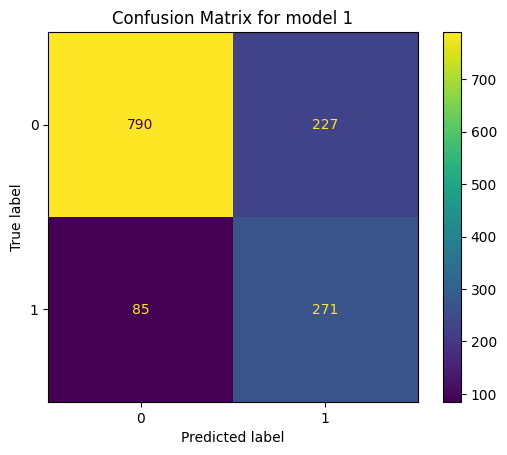

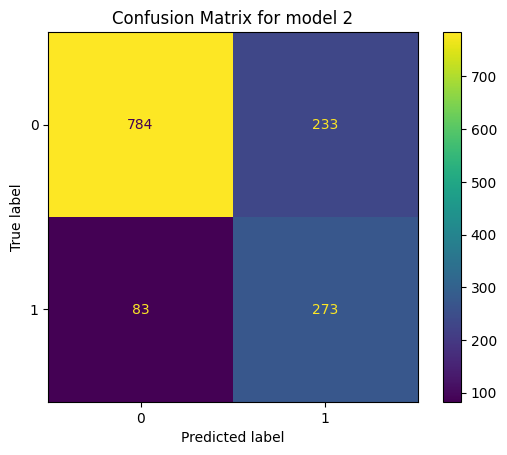

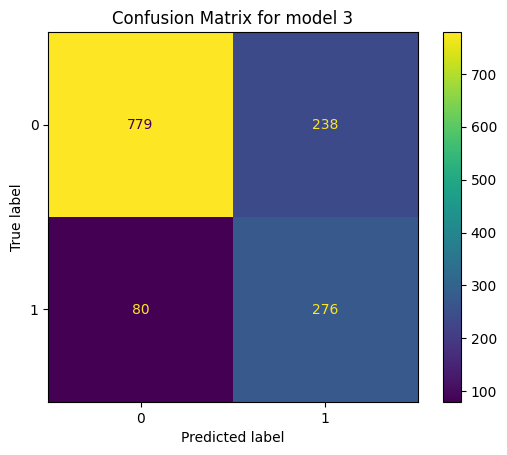

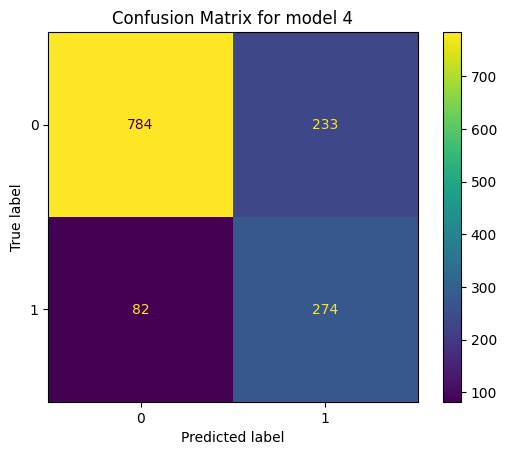

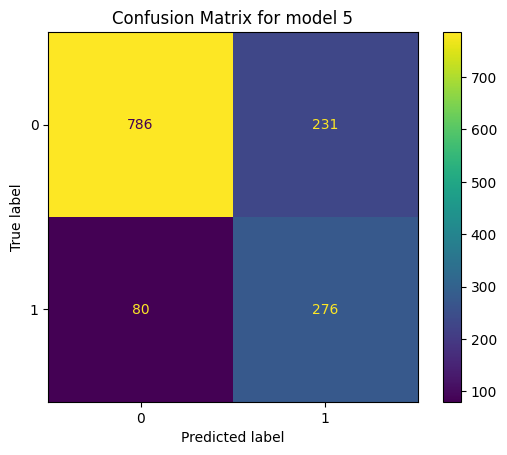

In [77]:
for index, estimator in enumerate(definitelylast_scores['estimator']):
    best_model = estimator.best_estimator_
    best_model.fit(X_train, y_train)
    predictions = best_model.predict(X_test)
    cm = confusion_matrix(y_test, predictions)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f'Confusion Matrix for model {index+1}')
    plt.show()

___

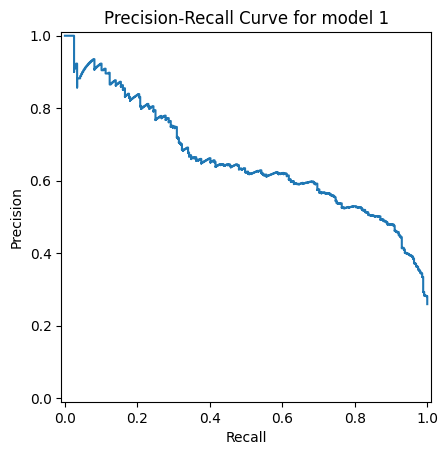

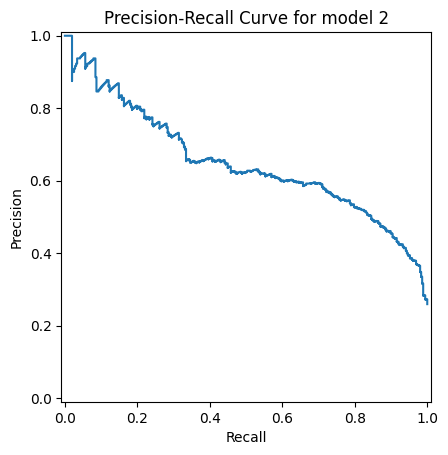

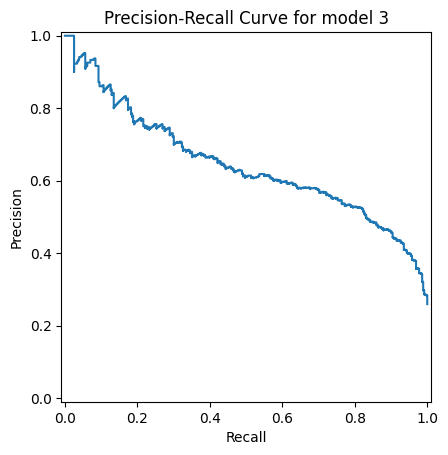

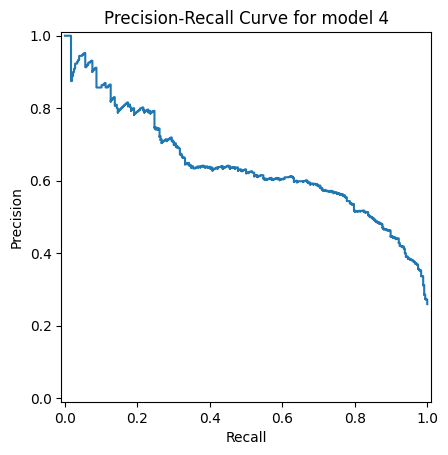

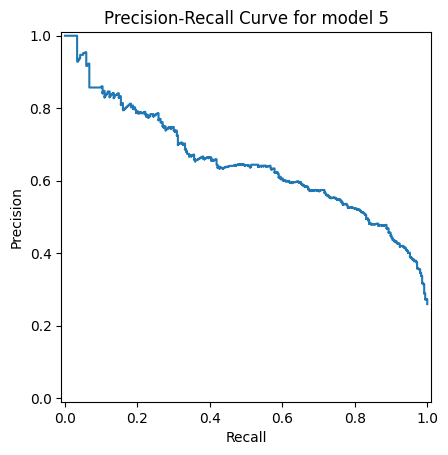

In [80]:
for index, estimator in enumerate(definitelylast_scores['estimator']):
    best_model = estimator.best_estimator_
    best_model.fit(X_train, y_train)  # Fit the model on training data
    pred_probs = best_model.predict_proba(X_test)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, pred_probs)
    disp = PrecisionRecallDisplay(precision=precision, recall=recall)
    disp.plot()
    plt.title(f'Precision-Recall Curve for model {index+1}')
    plt.show()

___


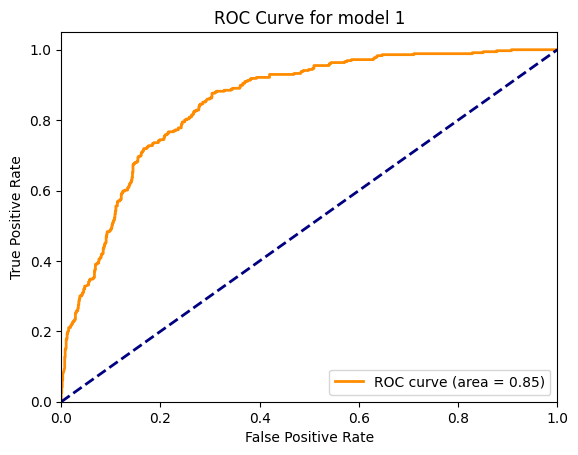

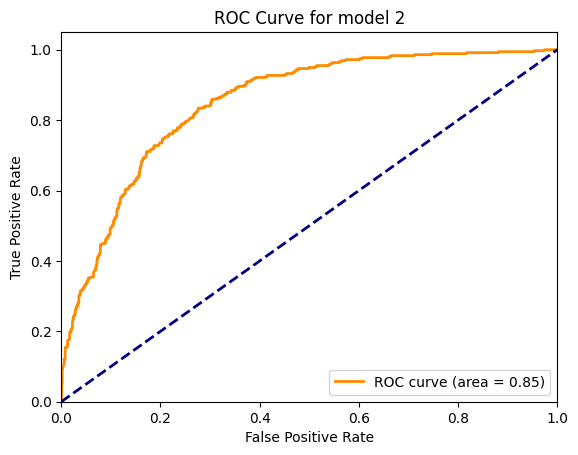

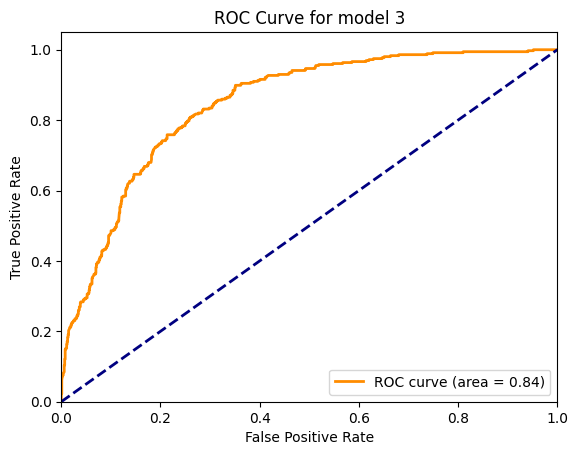

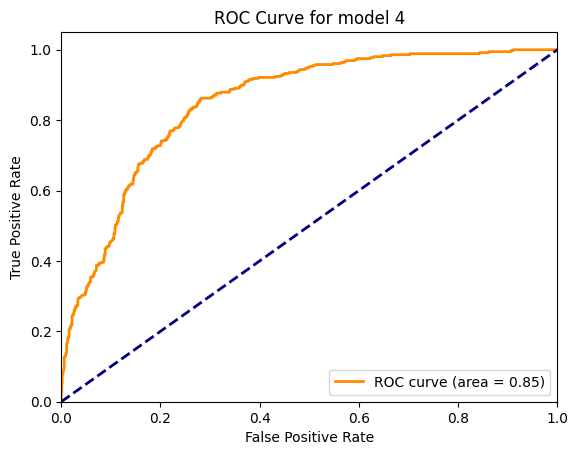

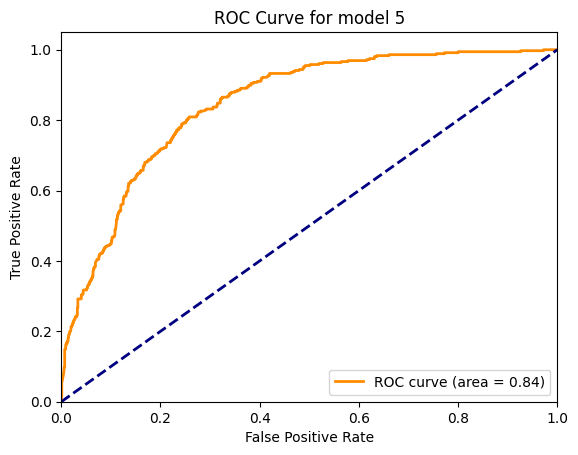

In [86]:
for index, estimator in enumerate(definitelylast_scores['estimator']):
    best_model = estimator.best_estimator_
    best_model.fit(X_train, y_train)  # Fit the model on training data
    pred_probs = best_model.predict_proba(X_test)[:, 1]

    fpr, tpr, thresholds = roc_curve(y_test, pred_probs)
    roc_auc = auc(fpr, tpr)

    # Plot the ROC Curve
    plt.figure()
    plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve for model {index+1}')
    plt.legend(loc="lower right")
    plt.show()

The five models are all similar in terms of performance, but i will chose the first as the best.

## Best Model


In [87]:
best_model = definitelylast_scores['estimator'][3].best_estimator_
best_model['classifier'].get_params()

{'objective': 'binary:logistic',
 'base_score': None,
 'booster': None,
 'callbacks': None,
 'colsample_bylevel': None,
 'colsample_bynode': None,
 'colsample_bytree': None,
 'device': None,
 'early_stopping_rounds': None,
 'enable_categorical': False,
 'eval_metric': 'logloss',
 'feature_types': None,
 'gamma': None,
 'grow_policy': None,
 'importance_type': None,
 'interaction_constraints': None,
 'learning_rate': np.float64(0.015002586990836422),
 'max_bin': None,
 'max_cat_threshold': None,
 'max_cat_to_onehot': None,
 'max_delta_step': None,
 'max_depth': 3,
 'max_leaves': None,
 'min_child_weight': None,
 'missing': nan,
 'monotone_constraints': None,
 'multi_strategy': None,
 'n_estimators': 400,
 'n_jobs': None,
 'num_parallel_tree': None,
 'random_state': None,
 'reg_alpha': None,
 'reg_lambda': None,
 'sampling_method': None,
 'scale_pos_weight': None,
 'subsample': 1.0,
 'tree_method': None,
 'validate_parameters': None,
 'verbosity': None,
 'use_label_encoder': False}

### Learnign Curve

In [90]:
train_sizes, train_scores, test_scores = learning_curve(best_model,
                                                       X=X_train,
                                                       y=y_train,
                                                       train_sizes= [0.01, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
                                                       cv = 5,
                                                       n_jobs = -1,
                                                       scoring = 'f1',
                                                       shuffle = False)

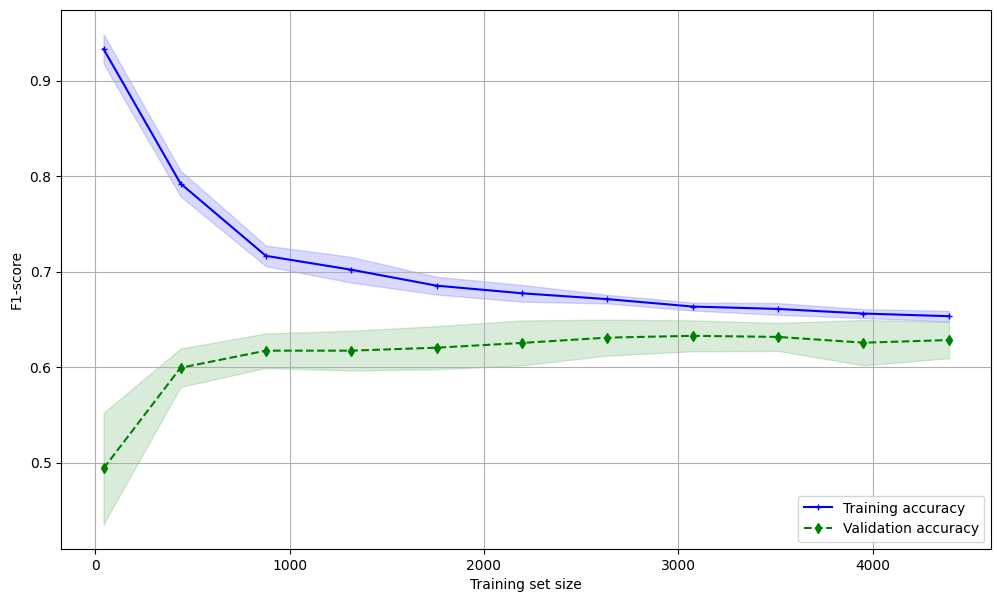

In [92]:
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

fig=plt.figure(figsize=(12,7))
ax = fig.add_subplot()

ax.plot(train_sizes, train_mean,
         color='blue', marker='+',
         markersize=5, label='Training accuracy')

ax.fill_between(train_sizes,
                 train_mean + train_std,
                 train_mean - train_std,
                 alpha=0.15, color='blue')

ax.plot(train_sizes, test_mean,
         color='green', linestyle='--',
         marker='d', markersize=5,
         label='Validation accuracy')

ax.fill_between(train_sizes,
                 test_mean + test_std,
                 test_mean - test_std,
                 alpha=0.15, color='green')

ax.grid()
ax.set_xlabel('Training set size')
ax.set_ylabel('F1-score')
ax.legend(loc='lower right')

In the end the final model is found.

In [96]:
best_model

Pipeline(steps=[('transformer',
                 ColumnTransformer(remainder='passthrough', sparse_threshold=0,
                                   transformers=[('pipeline1',
                                                  Pipeline(steps=[('imp',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('lable',
                                                                   OrdinalEncoder())]),
                                                  ['Partner', 'MultipleLines',
                                                   'PaperlessBilling',
                                                   'Dependents',
                                                   'PhoneService']),
                                                 ('pipeline2',
                                                  Pipeline(steps=[('custom1',
                                                                   CustomTransformer1()),...
                               importance_type=None,
                               interaction_constraints=None,
                               learning_rate=np.float64(0.015002586990836422),
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=3, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=400, n_jobs=None,
                               num_parallel_tree=None, random_state=None, ...))])

In [94]:
best_model.score(X_test, y_test)

0.7734887108521485

In [95]:
f1_score(y_test, best_model.predict(X_test))

0.6379511059371362